# `LocalPermutation`

`LocalPermutation` shuffles the rows of an n-site dataset so that each row moves **at most** `threshold` distance units — a spatially constrained permutation.  Unlike `LocalBootstrap`, each row appears **exactly once** (no replacement).  Optionally enforced as a **derangement**: no row may stay at its original site.

The algorithm to do this works in three steps. First, the universe of valid moves is populated. Second, the inital permutation is solved. Finally, the initial permutation is further mixed to generate new permutations. 

## Algorithm

1. **Build adjacency** — A[i,j] = True iff site j is within `threshold` of site i (diagonal blocked for derangements).  A `libpysal.graph.Graph` can be used instead, optionally combined with `threshold` to filter edges by weight.

2. **Initial permutation — Hungarian algorithm** — solve the *linear assignment problem*: find a complete matching between sites and values using only feasible pairs. Random costs in [0, 1] are assigned to feasible pairs for random tie-breaking, then `scipy.optimize.linear_sum_assignment` solves in O(n³).

3. **Markov chain mixing** — propose swapping `perm[i]` and `perm[j]` with frequency proportional to their weight; accept iff both moves stay within A and no fixed point is created. Run `n_burn` steps (default `10 * n`) between each yielded permutation.

In [1]:
import numpy
import geopandas
import matplotlib.pyplot as plt
import geodatasets
import colormaps
from spml.validation import LocalPermutation

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simple example — Chicago community areas

With 77 community areas we can clearly see how the derangement works. `bandwidth = 8 km` gives every area at least 3 swap partners.

The right panel shows **one permuted realisation**: each area displays the income of a nearby area that swapped with it.  
No area keeps its own value (derangement), and every value still appears exactly once.
Compare with `LocalBootstrap` where values can repeat.

In [2]:
chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_health")).to_crs("EPSG:32616")
chicago["income"] = chicago["PerCInc14"].fillna(chicago["PerCInc14"].median())
print(f"n = {len(chicago)} community areas")

n = 77 community areas


In [3]:
y = chicago["income"].values

lp_simple = LocalPermutation(bandwidth=8_000, derangement=True,
                             n_permutations=1, random_state=60666)
lp_k5 = LocalPermutation(k=5, derangement=True,
                         n_permutations=1, random_state=60605)
lp_global = LocalPermutation(bandwidth=100000, derangement=True,
                             n_permutations=1, random_state=60666)
perm_simple = next(lp_simple.sample(chicago))
perm_knn = next(lp_k5.sample(chicago))
perm_global = next(lp_global.sample(chicago))
y_perm_simple = y[perm_simple]
y_perm_k5 = y[perm_knn]
y_perm_global = y[perm_global]

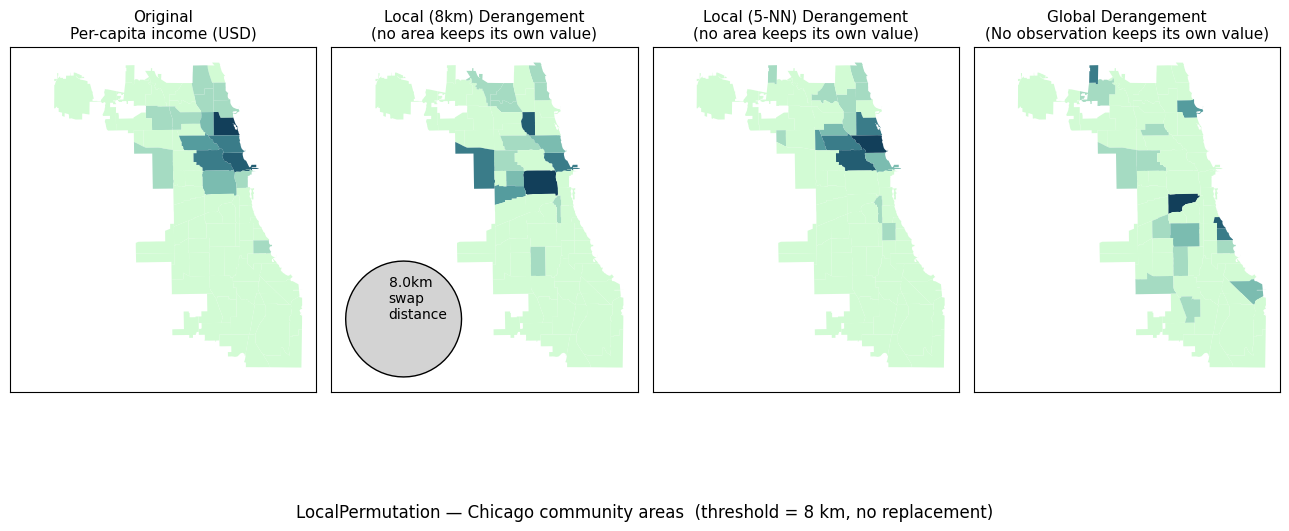

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 6), sharex=True, sharey=True)
PT = dict(
    cmap=colormaps.darkmint,
)

bw_poly = geopandas.GeoSeries(
    geopandas.points_from_xy(
        x=[425957],
        y=[4612218+5000]
    ),
    crs=chicago.crs
).buffer(lp_simple.bandwidth)

chicago.assign(_v=y).plot(column="_v", ax=axes[0], **PT)
axes[0].set_title("Original\nPer-capita income (USD)", fontsize=11)
chicago.assign(_v=y_perm_simple).plot(column="_v", ax=axes[1], **PT)
axes[1].set_title("Local (8km) Derangement\n(no area keeps its own value)", fontsize=11)
bw_poly.plot(ax=axes[1], color='lightgrey', edgecolor='k')
axes[1].text(x=425957-2000, y=4612218+5000, s=f"{lp_simple.bandwidth/1000:.1f}km\nswap\ndistance")

chicago.assign(_v=y_perm_k5).plot(column="_v", ax=axes[2], **PT)
axes[2].set_title("Local (5-NN) Derangement\n(no area keeps its own value)", fontsize=11)

chicago.assign(_v=chicago.sample(frac=1, replace=False).income.values).plot(column="_v", ax=axes[3], **PT)
axes[3].set_title("Global Derangement\n(No observation keeps its own value)", fontsize=11)
for i,ax in enumerate(axes.flat):
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

fig.suptitle("LocalPermutation — Chicago community areas  (threshold = 8 km, no replacement)", fontsize=12, y=0)
fig.tight_layout()
plt.show()

Use local permutations instead of local bootstraps when the sample size is small. Otherwise, [local bootstraps](local_bootstrap.ipynb) are more performant, and will behave nearly identically to the outcomes discussed here, since the probability of replacement is proportional to the bootstrap. Both classes can admit arbitrary `libpysal.graph.Graph` objects, and the samples respect the weights in that graph. 

---

## Application: time series

These techniques do not need to only be used in spatial data; they can also be used in temporal data. Permutation here helps keep the original signal reasonable, since all values will occur eventually, jsut a few days after (or before) they were intended to occur! This is a bit clearer from a practical perspective. 

First, let's simulate an AR(3) process with strong autocorrelation.

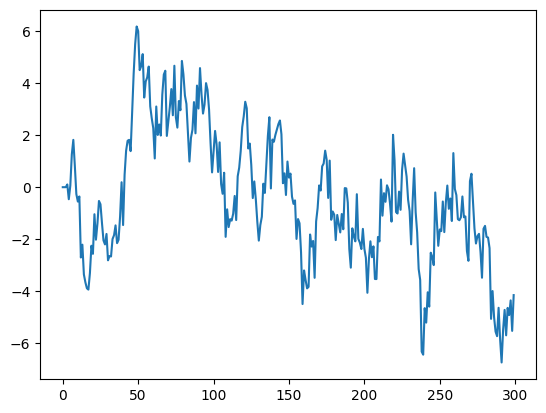

In [5]:
# --- simulate AR(3) ---------------------------------------------------
# phi chosen so sum ~ 0.95: strongly autocorrelated, random-walk-like
rng = numpy.random.default_rng(0)
T   = 300
phi = [0.7, 0.2, 0.05]

eps = rng.normal(0, 1, T)
y   = numpy.zeros(T)
for t in range(3, T):
    y[t] = phi[0]*y[t-1] + phi[1]*y[t-2] + phi[2]*y[t-3] + eps[t]
plt.plot(y)

We can see that the sequence is strongly autocorrelated. To use local permutation here, the `threshold` parameter identifies how far separated in time the observations might be if we want to allow swapping. Here, let's allow swaps between a varying number of units. As the number of units increases, the autocorrelation goes to zero. The top facet can only permute within 2 spaces, so all the values in the sequence must occur within 2 time periods of their original location. This strongly limits the variability of admissible sequences. The bottom facet, however, allows any permutation where observations can fall within 150 time periods of their original location---half of the time period in the sequence. This means that basically all dependence is broken. 

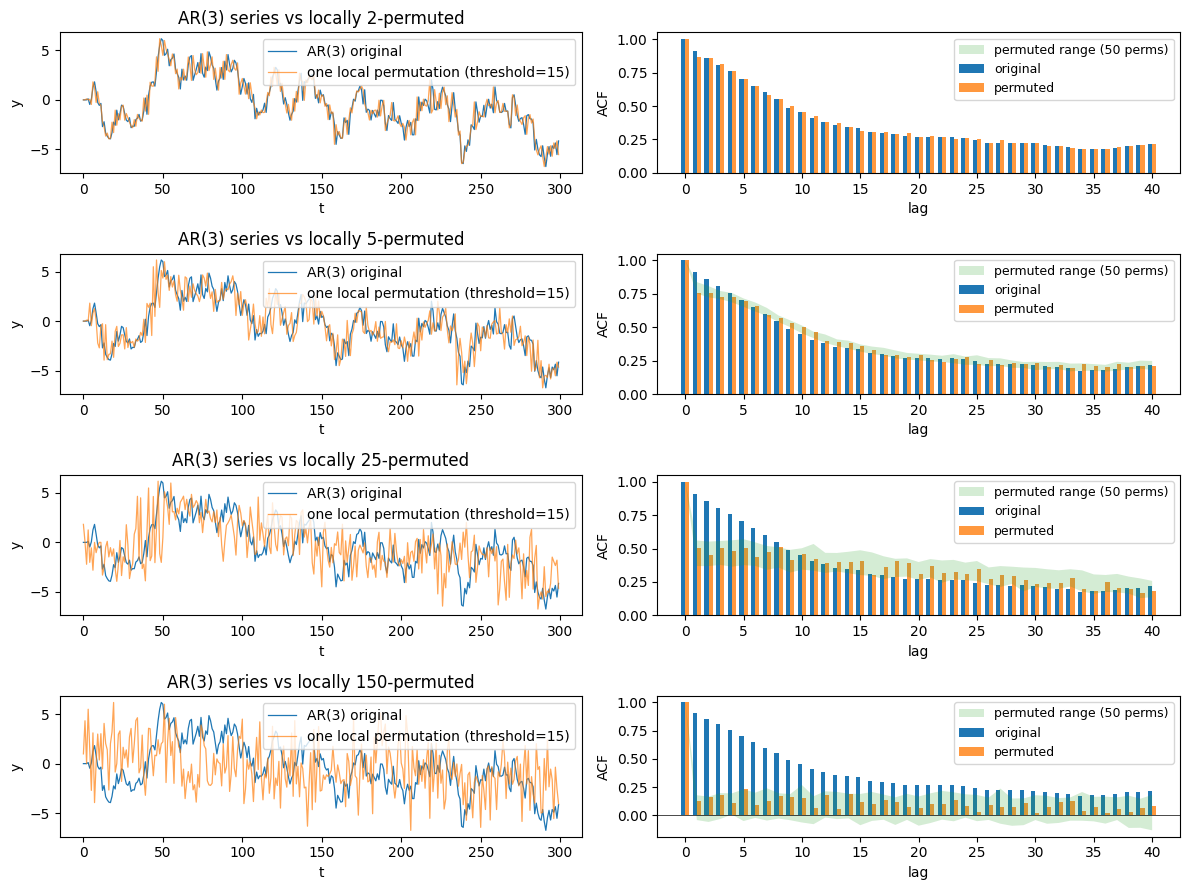

In [7]:
t  = numpy.arange(T, dtype=float)

fig, axes = plt.subplots(4,2, figsize=(12, 9), sharex=False)
axes=axes.T
for ti, bandwidth_ in enumerate((2, 5, 25, 150)):
    lp = LocalPermutation(bandwidth=bandwidth_, n_permutations=50, random_state=85281)
    perms = list(lp.sample(t))
    perm  = perms[0]
    y_perm = y[perm]

    def acf(x, max_lag=40):
        x = x - x.mean()
        return numpy.array([
            numpy.dot(x[k:], x[:T-k]) / numpy.dot(x, x)
            for k in range(max_lag + 1)
        ])

    lags      = numpy.arange(41)
    acf_orig  = acf(y)
    acf_perm  = acf(y_perm)
    # envelope across all 50 permutations
    acf_all   = numpy.stack([acf(y[p]) for p in perms])

    # Panel 1 -- time series
    axes[0, ti].plot(y,      lw=0.9, label="AR(3) original")
    axes[0, ti].plot(y_perm, lw=0.9, alpha=0.7, label="one local permutation (threshold=15)")
    axes[0, ti].set_xlabel("t")
    axes[0, ti].set_ylabel("y")
    axes[0, ti].set_title(f"AR(3) series vs locally {bandwidth_}-permuted")
    axes[0, ti].legend()

    # Panel 2 -- ACF comparison
    w = 0.35
    axes[1, ti].bar(lags - w/2, acf_orig,  w, label="original")
    axes[1, ti].bar(lags + w/2, acf_perm,  w, label="permuted", alpha=0.8)
    axes[1, ti].fill_between(lags, acf_all.min(0), acf_all.max(0),
                        alpha=0.2, label="permuted range (50 perms)")
    axes[1, ti].axhline(0, color="k", lw=0.5)
    axes[1, ti].set_xlabel("lag")
    axes[1, ti].set_ylabel("ACF")
    axes[1, ti].legend(fontsize=9)

plt.tight_layout()
plt.show()